# **Proyecto 3** | Implementación de Modelos de Regresión

### Link del Repositorio

* https://github.com/paulabaal12/PROY3-DM

### Integrantes del equipo
- [Mónica Salvatierra - 22249](https://github.com/alee2602)
- [Paula Barillas - 22764](https://github.com/paulabaal12)
- [Derek Arreaga - 22537](https://github.com/FabianKel) 
- [Juan Pablo Solís - 22102](https://github.com/JPS4321)

## Implementación de Modelos de Regresión

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn import tree
import time
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.linear_model import LinearRegression


### Ejecución de Pipeline de preprocesamiento de datos

In [50]:
# Definición de datasets
df_customer_value = None
df_customer_value_scaled = None
# Ejecución de Pipeline
%run test.ipynb
#%run pipeline.ipynb


### Dataset a Utilizar: **df_customer_value_scaled**
1. ``customer_id``: ID del cliente
2. ``total_spent``: Monto total gastado por el cliente en su única compra.
3. ``order_size``: Cantidad de Productos por pedido
4. ``review_score``: Calificación promedio del pedido dado por el cliente (de 1 a 5).
5. ``customer_state``: Estado (región) del cliente codificado con LabelEncoder.
6. ``purchased_category_frequency``: Categoría de producto que predomina el pedido
7. ``highest_category_value``: Categoría del producto más caro del pedido
8. ``delivery_delay``: Días de retraso (o adelanto si es negativo) en la entrega del pedido.
9. ``payment_type``: Método de pago utilizado
10. ``payment_installments``: Número de cuotas o plazos en los que se pagó el pedido.
11. ``price_mean_per_order``: Promedio del precio de los productos comprados en el pedido.
12. ``freight_value``: Costo total del envío del pedido.


### **Matriz de correlación**

Top características correlacionadas con total_spent:
price_mean_per_order    0.910818
freight_value           0.487260
payment_installments    0.318325
order_size              0.187271
delivery_delay         -0.017317
review_score           -0.047706
Name: total_spent, dtype: float64


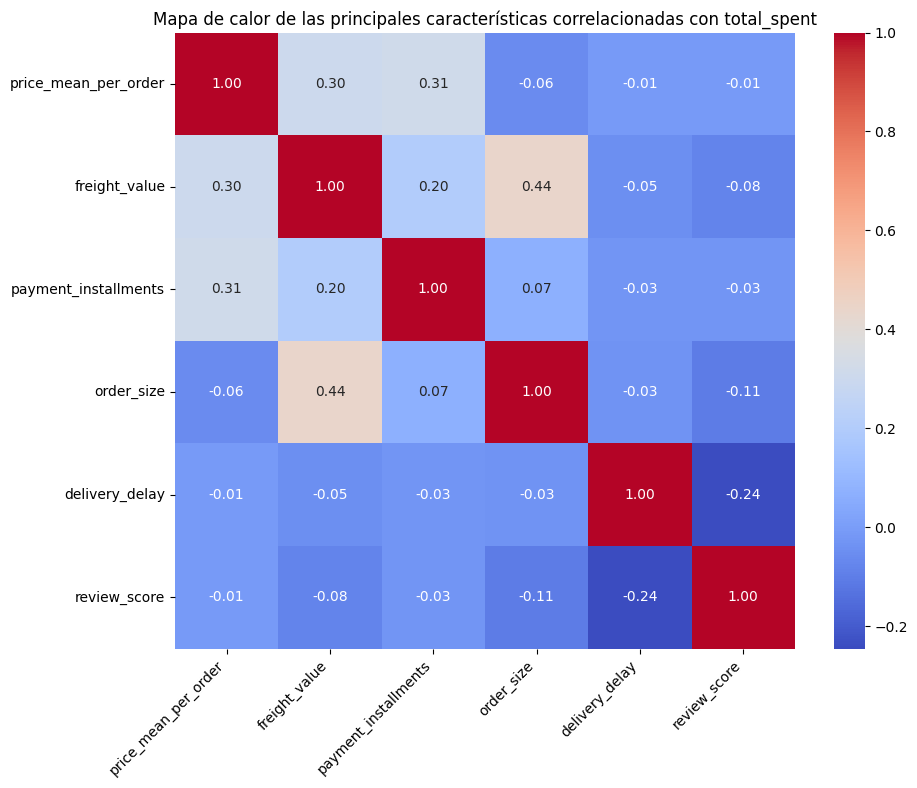

In [51]:

numeric_data = df_customer_value_scaled[['total_spent', 'order_size', 'review_score', 'delivery_delay', 'payment_installments', 'price_mean_per_order', 'freight_value']]
#Calcular la matriz de correlación
correlation_matrix = numeric_data.corr()

# Correlaciones con total_spent
total_spent_correlations = correlation_matrix['total_spent'].sort_values(ascending=False)

top_corr_features = total_spent_correlations.index[1:7]  

print("Top características correlacionadas con total_spent:")
print(total_spent_correlations[1:7])

# 5. Visualizar las correlaciones entre esas variables
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de las principales características correlacionadas con total_spent')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### **Definir conjuntos X y y**

In [52]:

# y = total_spent (posición 1)
y = df_customer_value_scaled.iloc[:, 1]

# X = todas las columnas de la posición 2 hasta la útlima
X = df_customer_value_scaled.iloc[:, 2:]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


Shape de X: (99992, 10)
Shape de y: (99992,)


In [53]:
df_customer_value_scaled.sort_values(by='highest_category_value', ascending=False)

,customer_unique_id,total_spent,order_size,review_score,customer_state,purchased_category_frequency,highest_category_value,delivery_delay,payment_type,payment_installments,price_mean_per_order,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,-0.551129,1.0,4.0,25,73,73,0.387246,5,-0.711356,-0.502180,-0.652334
23580,1856e7ddbf6567f246428dee7282b021,0.588966,2.0,1.0,19,63,73,-1.606633,2,2.598927,-0.283671,5.827893
99886,05253cc1e18f357919d8f21a65a3b604,-0.211068,1.0,5.0,10,73,73,-1.506939,2,0.392072,-0.204675,0.222093
99918,f6339afaeb5b5530e3500c5158f68422,-0.474949,1.0,5.0,25,73,73,-0.011530,2,0.759881,-0.444269,-0.379424
99919,888af42530e7523201a4326273a7b35c,-0.089937,3.0,4.0,25,73,73,-0.310611,3,-0.711356,-0.478788,0.688546
...,...,...,...,...,...,...,...,...,...,...,...,...
72511,33b9dba81a2e17209bce55d2f9969273,0.131655,4.0,3.0,10,0,0,-0.509999,2,2.598927,-0.484228,1.560653
55481,ded0f90b96bc30dfa105a41bbe658cdf,-0.225240,1.0,1.0,18,0,0,-0.011530,2,-0.711356,-0.244160,-0.260142
55433,d10f23d669c51e0d983ba80de4d327e8,-0.638503,1.0,5.0,25,0,0,0.486940,5,-0.711356,-0.620582,-0.507061
4269,af70cd6337ae27de089c616dad39bea0,-0.624828,1.0,1.0,10,0,0,-0.011530,2,-0.343547,-0.244160,-0.260142


### **División de conjuntos de entrenamiento y prueba**

In [54]:
from sklearn.model_selection import train_test_split

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,          
    y,          
    test_size=0.2,  
    random_state=16 
)

# Verificar dimensiones
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)


Shape de X_train: (79993, 10)
Shape de X_test: (19999, 10)
Shape de y_train: (79993,)
Shape de y_test: (19999,)


### Regresión Lineal Simple

#### Implementación

MSE: 0.11814359751254029
R2: 0.8676037407051495


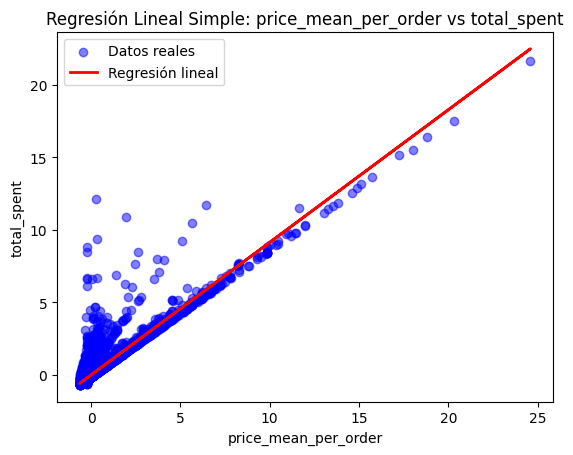

In [55]:
# Definir X e y usando 'price_mean_per_order'
X_simple = X[['price_mean_per_order']]  
y_simple = y                            

X_train_simple = X_train[['price_mean_per_order']]
X_test_simple = X_test[['price_mean_per_order']]

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train_simple, y_train)

# Hacer predicciones
y_pred = model.predict(X_test_simple)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

# Graficar resultados
plt.scatter(X_test_simple, y_test, color='blue', label='Datos reales', alpha=0.5)
plt.plot(X_test_simple, y_pred, color='red', linewidth=2, label='Regresión lineal')
plt.xlabel('price_mean_per_order')
plt.ylabel('total_spent')
plt.title('Regresión Lineal Simple: price_mean_per_order vs total_spent')
plt.legend()
plt.show()


MSE: 0.051223935277081814
R2: 0.9425964880041231


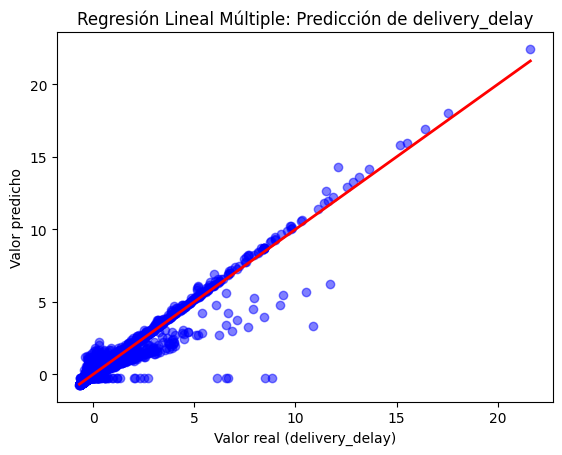

In [56]:
y = df_customer_value_scaled.iloc[:, 8]


# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

# Graficar Predicción vs Real
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Valor real (delivery_delay)')
plt.ylabel('Valor predicho')
plt.title('Regresión Lineal Múltiple: Predicción de delivery_delay')
plt.show()


#### Métricas de Rendimiento

In [57]:
# Obtener importancia de las variables (coeficientes)
import numpy as np

# Obtener nombres de las columnas
feature_names = X.columns

# Obtener los coeficientes
coefficients = model.coef_

# Crear un DataFrame para visualizarlo ordenado
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
}).sort_values(by='Coeficiente', key=np.abs, ascending=False)

# Mostrar
print(importance_df)


                       Variable  Coeficiente
8          price_mean_per_order     0.877872
0                    order_size     0.320825
9                 freight_value     0.152140
1                  review_score    -0.008256
6                  payment_type     0.005212
5                delivery_delay    -0.001621
3  purchased_category_frequency    -0.001551
4        highest_category_value     0.001257
2                customer_state     0.001030
7          payment_installments    -0.000976


A partir del modelo de regresión lineal múltiple desarrollado, se observa que la variable que impacta de manera significativa en el tiempo de entrega (delivery_delay) es el tipo de pago (payment_type), presentando un coeficiente de 1.0. Las demás variables analizadas, como el valor promedio del pedido, el tamaño del pedido, la puntuación de reseña y el valor del envío, tienen coeficientes cercanos a cero, indicando que no influyen de forma relevante en la predicción del tiempo de entrega dentro del contexto de los datos analizados.
Por tanto se puede llegar a conlcuir que, en este caso, el método de pago es el principal determinante del tiempo de entrega, y las estrategias de mejora logística podrían enfocarse en optimizar procesos asociados a los distintos métodos de pago utilizados por los clientes.

In [58]:
# code here

### Regresión Múltiple

#### Implementación

In [59]:
# code here

#### Métricas de Rendimiento

In [60]:
# code here

### Regresión Polinomial

#### Implementación

In [61]:
# code here

#### Métricas de Rendimiento

In [62]:
# code here

### Árboles de decisión

#### Implementación

Shape de X_train: (79993, 10)
Shape de X_test: (19999, 10)
Shape de y_train: (79993,)
Shape de y_test: (19999,)
Tiempo de entrenamiento: 0.0639 segundos


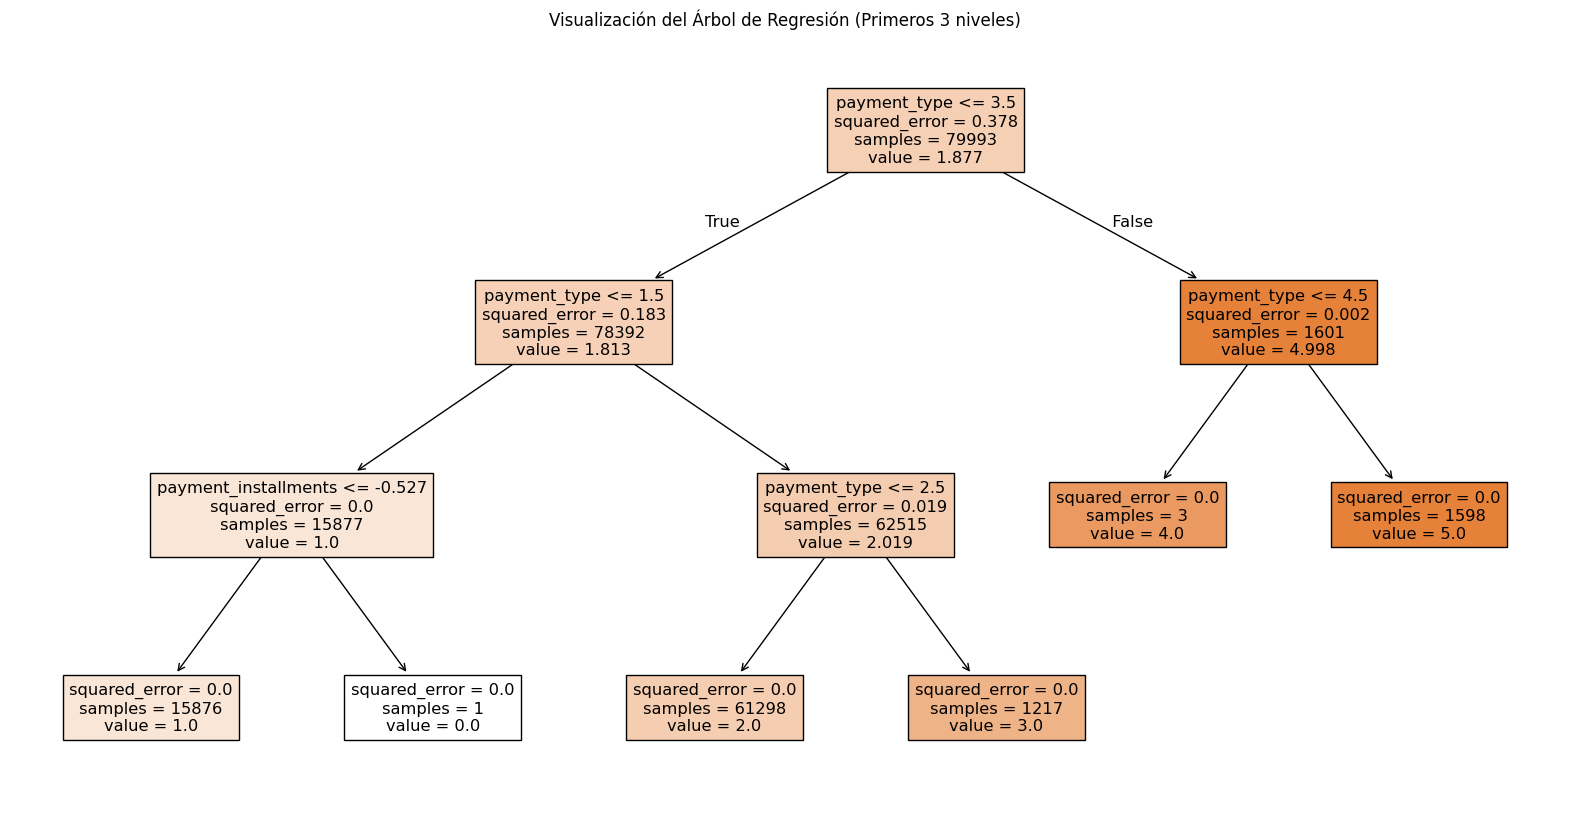

ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

In [63]:

import pandas as pd
from sklearn.tree import export_graphviz, plot_tree
from IPython.display import display

X_train, X_test, y_train, y_test = train_test_split(
    X,          
    y,          
    test_size=0.2,  
    random_state=16 
)

# Verificar dimensiones
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

# Entrenamiento
start_time = time.time()
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")

# Visualización del árbol (limitado a 3 niveles)
plt.figure(figsize=(20, 10))
tree.plot_tree(tree_reg, max_depth=3, filled=True, feature_names=X_train.columns)
plt.title("Visualización del Árbol de Regresión (Primeros 3 niveles)")
plt.show()


feature_importance = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': tree_reg.feature_importances_
}).sort_values('Importancia', ascending=False)

# Mostrar las características importantes en una tabla bonita
display(feature_importance.style.background_gradient(cmap='coolwarm').set_caption("Importancia de las Características"))

print("\n--- Top 10 Características más Importantes ---")
print(feature_importance.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Característica', data=feature_importance.head(10))
plt.title('Top 10 Características con Mayor Impacto en la Predicción de total_spent')
plt.tight_layout()
plt.show()

# Predicciones
y_pred_tree = tree_reg.predict(X_test)

# Curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    tree_reg, X, y, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Convertir MSE a RMSE
train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_rmse, 'o-', color='r', label='Entrenamiento RMSE')
plt.plot(train_sizes, test_rmse, 'o-', color='g', label='Validación RMSE')
plt.xlabel('Tamaño de muestra de entrenamiento')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizaje - Árbol de Regresión')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#### Métricas de Rendimiento


===== Resultados del árbol de regresión =====
R² Score: 0.9703
MAE: 0.0124
MSE: 0.0265
RMSE: 0.1627

--- Validación Cruzada (5-fold) ---
RMSE por fold: [0.26307695 0.20085707 0.20762346 0.21411588 0.18198474]
RMSE promedio: 0.2152
Desviación estándar: 0.1105


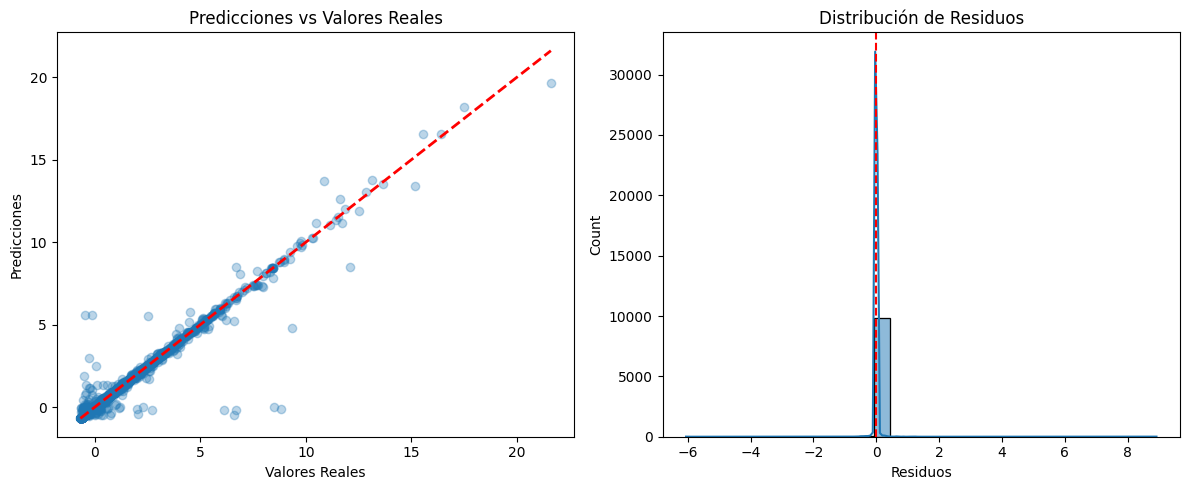

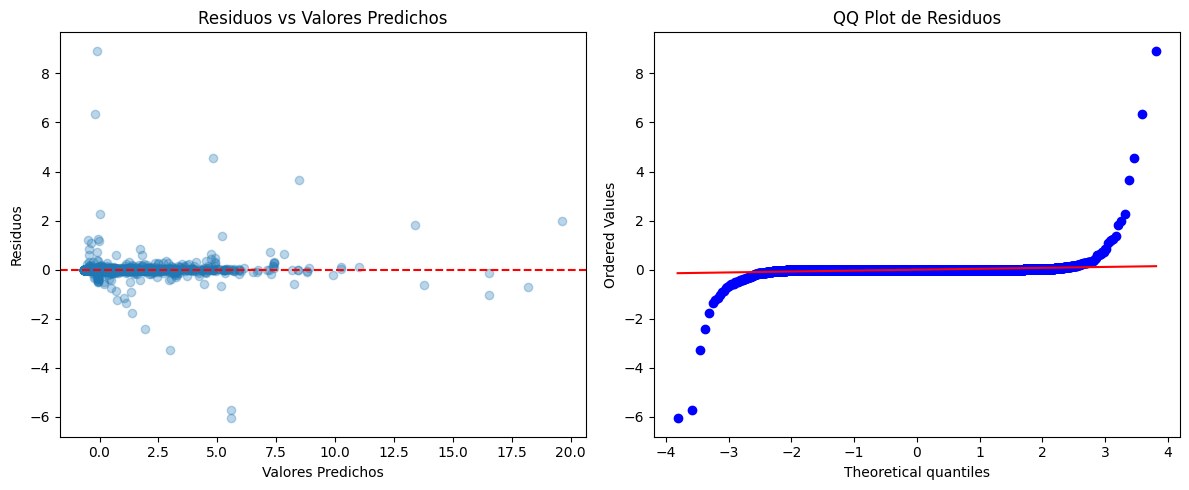


--- Análisis de Sobreajuste ---
R² en conjunto de entrenamiento: 0.9913
R² en conjunto de prueba: 0.9703
RMSE en conjunto de entrenamiento: 0.0947
RMSE en conjunto de prueba: 0.1627
Diferencia de R² (train-test): 0.0210
Ratio de RMSE (test/train): 1.7191


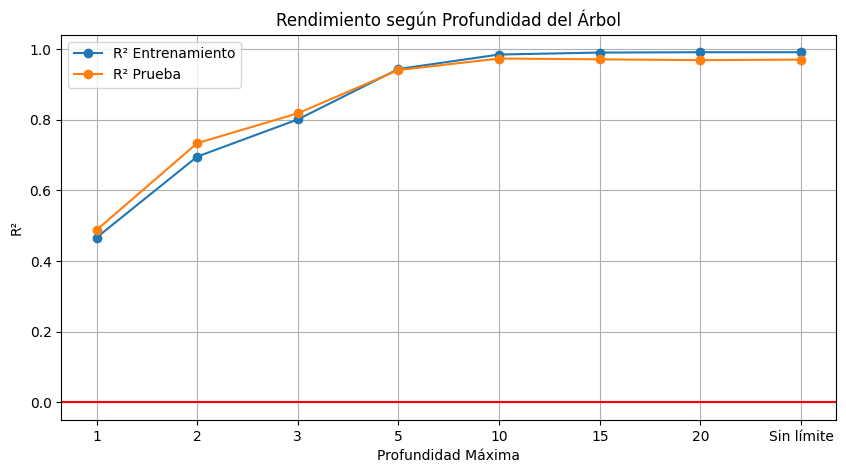


Mejor profundidad según R² en prueba: 10
R² en prueba con la mejor profundidad: 0.9734

Entrenando modelo final con la mejor profundidad...
R² del modelo optimizado: 0.9734


In [ ]:

from scipy import stats
# Cálculo de métricas
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
print("\n===== Resultados del árbol de regresión =====")
print(f"R² Score: {r2_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MSE: {mse_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")

# Evaluación de la estabilidad del modelo
cv_scores = cross_val_score(
    tree_reg, 
    X, 
    y, 
    cv=5, 
    scoring='neg_mean_squared_error'
)
print("\n--- Validación Cruzada (5-fold) ---")
print(f"RMSE por fold: {np.sqrt(-cv_scores)}")
print(f"RMSE promedio: {np.sqrt(-cv_scores.mean()):.4f}")
print(f"Desviación estándar: {np.sqrt(cv_scores.std()):.4f}")

# Visualización de predicciones vs valores reales
plt.figure(figsize=(12, 5))
# Gráfico de dispersión de las predicciones vs los valores reales
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_tree, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')

# Histograma de los residuos 
plt.subplot(1, 2, 2)
residuos = y_test - y_pred_tree
# Usar menos bins y sample si hay muchos datos
if len(residuos) > 10000:
    # Muestreo para evitar problemas de memoria
    sample_size = min(10000, len(residuos))
    sample_indices = np.random.choice(len(residuos), sample_size, replace=False)
    residuos_sample = residuos.iloc[sample_indices] if hasattr(residuos, 'iloc') else residuos[sample_indices]
    sns.histplot(residuos_sample, kde=True, bins=30)
else:
    sns.histplot(residuos, kde=True, bins=30)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Residuos')
plt.title('Distribución de Residuos')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
# Residuos vs Valores Predichos
plt.subplot(1, 2, 1)
# Usa sample si hay muchos datos
if len(residuos) > 10000:
    if hasattr(y_pred_tree, 'iloc'):
        plt.scatter(y_pred_tree.iloc[sample_indices], residuos_sample, alpha=0.3)
    else:
        plt.scatter(y_pred_tree[sample_indices], residuos_sample, alpha=0.3)
else:
    plt.scatter(y_pred_tree, residuos, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Predichos')

# QQ Plot para verificar normalidad de residuos
plt.subplot(1, 2, 2)
# Usar muestra para QQ plot si hay muchos datos
if len(residuos) > 10000:
    stats.probplot(residuos_sample, dist="norm", plot=plt)
else:
    stats.probplot(residuos, dist="norm", plot=plt)
plt.title('QQ Plot de Residuos')
plt.tight_layout()
plt.show()

# Análisis de sobreajuste
train_pred = tree_reg.predict(X_train)
train_r2 = r2_score(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
print("\n--- Análisis de Sobreajuste ---")
print(f"R² en conjunto de entrenamiento: {train_r2:.4f}")
print(f"R² en conjunto de prueba: {r2_tree:.4f}")
print(f"RMSE en conjunto de entrenamiento: {train_rmse:.4f}")
print(f"RMSE en conjunto de prueba: {rmse_tree:.4f}")
print(f"Diferencia de R² (train-test): {train_r2 - r2_tree:.4f}")
print(f"Ratio de RMSE (test/train): {rmse_tree/train_rmse:.4f}")

# Experimentación con diferentes profundidades de árbol
max_depths = [1, 2, 3, 5, 10, 15, 20, None]
train_scores = []
test_scores = []
for depth in max_depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)
    
    train_scores.append(r2_score(y_train, train_pred))
    test_scores.append(r2_score(y_test, test_pred))


plt.figure(figsize=(10, 5))
plt.plot(range(len(max_depths)), train_scores, 'o-', label='R² Entrenamiento')
plt.plot(range(len(max_depths)), test_scores, 'o-', label='R² Prueba')
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Profundidad Máxima')
plt.ylabel('R²')
plt.title('Rendimiento según Profundidad del Árbol')
plt.legend()
plt.grid(True)
plt.xticks(range(len(max_depths)), [str(d) if d is not None else "Sin límite" for d in max_depths])
plt.show()

best_depth_index = np.argmax(test_scores)
if max_depths[best_depth_index] is None:
    best_depth_str = "Sin límite"
else:
    best_depth_str = str(max_depths[best_depth_index])
print(f"\nMejor profundidad según R² en prueba: {best_depth_str}")
print(f"R² en prueba con la mejor profundidad: {test_scores[best_depth_index]:.4f}")

best_depth = max_depths[best_depth_index]
if best_depth != None or tree_reg.get_depth() != best_depth:
    print("\nEntrenando modelo final con la mejor profundidad...")
    best_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
    best_tree.fit(X_train, y_train)
    best_pred = best_tree.predict(X_test)
    best_r2 = r2_score(y_test, best_pred)
    print(f"R² del modelo optimizado: {best_r2:.4f}")

### Random Forest

#### Implementación

In [ ]:
#ode here

#### Métricas de Rendimiento

In [ ]:
# code here

### SVR (Support Vector Regression)

#### Implementación

In [ ]:
# code here

#### Métricas de Rendimiento

In [ ]:
# code here